In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
customers = pd.read_csv('/Volumes/AlexHD/2. Analyst Builder/1. Raw/Statistics Course/files/customers.csv')
orders = pd.read_csv('/Volumes/AlexHD/2. Analyst Builder/1. Raw/Statistics Course/files/orders.csv')
orders['order_date'] = pd.to_datetime(orders['order_date'])

In [18]:

customers

,customer_id,age,gender,region,signup_days_ago,lifetime_value,loyalty_tier
0,C00001,43,Male,Southeast,1372,77.80,Bronze
1,C00002,36,Male,Northeast,290,74.74,Bronze
2,C00003,45,Male,Southwest,1334,33.35,Bronze
3,C00004,56,Male,Southeast,1382,510.70,Silver
4,C00005,35,Male,Southeast,1177,515.37,Silver
5,C00006,35,Female,Northeast,1529,522.80,Silver
6,C00007,56,Female,Southeast,307,322.50,Silver
7,C00008,47,Female,Southwest,122,35.88,Bronze
8,C00009,32,Male,Southeast,988,97.12,Bronze
9,C00010,44,Male,Southwest,1600,285.25,Bronze


In [4]:
ltv = customers['lifetime_value']

In [19]:
ltv

0          77.80
1          74.74
2          33.35
3         510.70
4         515.37
5         522.80
6         322.50
7          35.88
8          97.12
9         285.25
10        276.43
11        200.24
12        341.05
13        247.27
14        272.79
15        137.67
16        592.18
17        166.05
18         73.88
19        122.25
20        178.82
21        598.61
22        235.56
23        206.95
24         79.54
25        496.18
26        136.08
27        223.63
28        927.20
29        386.79
30         56.52
31         49.77
32        230.93
33         82.15
34        438.65
35        254.18
36        283.96
37        129.53
38       1172.91
39       3160.02
40        190.43
41        336.21
42        267.11
43        193.69
44        115.72
45         92.16
46         88.06
47        352.38
48        153.28
49         24.04
50        365.17
51        236.41
52        822.22
53        342.34
54         64.66
55         32.89
56        128.06
57        139.41
58        571.

In [6]:
print(f"Mean:  ${ltv.mean():.2f}")
print(f"Median:  ${ltv.median():.2f}")
print(f"Mode:  ${ltv.mode().iloc[0]:.2f}")


Mean:  $380.05
Median:  $251.99
Mode:  $144.28


In [8]:
ltv.sort_values().reset_index(drop=True)

0           9.28
1          12.22
2          12.46
3          13.13
4          15.11
5          15.27
6          16.92
7          17.14
8          17.42
9          17.45
10         17.80
11         18.39
12         18.72
13         18.92
14         19.33
15         19.37
16         19.42
17         19.98
18         20.45
19         20.47
20         20.51
21         21.93
22         22.43
23         23.01
24         23.21
25         23.45
26         24.04
27         24.21
28         24.27
29         24.27
30         24.30
31         24.58
32         24.65
33         24.81
34         25.07
35         25.14
36         25.32
37         25.55
38         26.20
39         26.48
40         27.18
41         27.44
42         27.47
43         27.68
44         27.75
45         27.83
46         27.90
47         28.17
48         28.27
49         28.42
50         28.65
51         28.79
52         28.97
53         29.29
54         29.89
55         30.42
56         30.49
57         30.62
58         30.

In [10]:
# Mean

ltv.sum()/ltv.count()

np.float64(380.05244400000004)

In [16]:
# Median - center value

sorted_ltv = ltv.sort_values().reset_index(drop=True)

n = sorted_ltv.count()

mid_right = n // 2

mid_right

mid_left = mid_right - 1

mid_left

np.int64(2499)

In [17]:
median = (sorted_ltv[mid_right] + sorted_ltv[mid_left]) / 2

median

np.float64(251.985)

In [22]:
# Mode

counts = ltv.value_counts()

max_count = counts.max()

counts[counts==max_count].index


Index([301.38, 144.28], dtype='float64', name='lifetime_value')

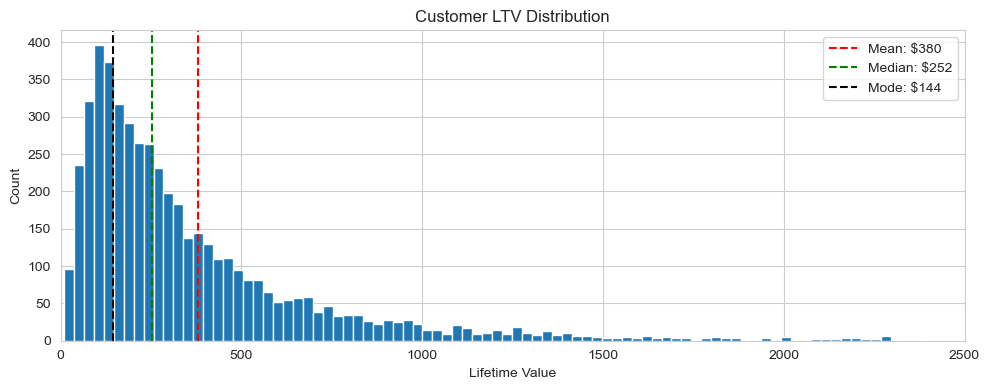

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ltv, bins=500, edgecolor='white')
ax.axvline(ltv.mean(), color='red', linestyle='--', label=f'Mean: ${ltv.mean():.0f}')
ax.axvline(ltv.median(), color='green', linestyle='--', label=f'Median: ${ltv.median():.0f}')
ax.axvline(ltv.mode()[0], color='black', linestyle='--', label=f'Mode: ${ltv.mode()[0]:.0f}')
ax.set_xlabel('Lifetime Value')
ax.set_ylabel('Count')
ax.set_title('Customer LTV Distribution')
ax.set_xlim(0, 2500)
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
orders = pd.read_csv('/Volumes/AlexHD/2. Analyst Builder/1. Raw/Statistics Course/files/orders.csv')
orders['order_date'] = pd.to_datetime(orders['order_date'])


values = orders['order_value']
mean = values.mean()

#step 1 - find out how far each order is from the average

deviations = values - mean

# step 2 - square the deviation

squared_devs = deviations ** 2

#step 3 - average the sqaured deviations

variance = squared_devs.mean()

# step 4 - Square it

std_manual = np.sqrt(variance)


std_pandas = values.std()


print(std_manual)
print(std_pandas)
print(mean)

68.01612975699338
68.01839707468523
106.17991933333333


In [25]:
orders

,order_id,customer_id,order_date,category,num_items,order_value,shipping_cost,days_to_deliver
0,O000001,C02264,2024-05-11,Clothing,3,96.79,0.00,6
1,O000002,C00283,2024-03-22,Sports,3,139.56,0.00,4
2,O000003,C02621,2024-12-05,Home,2,96.32,0.00,3
3,O000004,C03287,2024-10-22,Clothing,4,153.17,0.00,7
4,O000005,C00172,2024-12-25,Electronics,4,118.65,0.00,3
5,O000006,C03457,2024-04-21,Clothing,1,24.29,12.82,3
6,O000007,C01883,2024-10-29,Sports,4,194.54,0.00,7
7,O000008,C02276,2024-11-01,Electronics,2,54.11,6.98,3
8,O000009,C02622,2024-02-20,Beauty,5,184.96,0.00,4
9,O000010,C00601,2024-10-20,Home,4,190.64,0.00,3


Within 1 SD ($38 - $174): 70.6%  (theory: 68%)
Within 2 SD ($-30 - $242): 95.7%  (theory: 95%)
Within 3 SD ($-98 - $310): 98.8%  (theory: 99.7%)


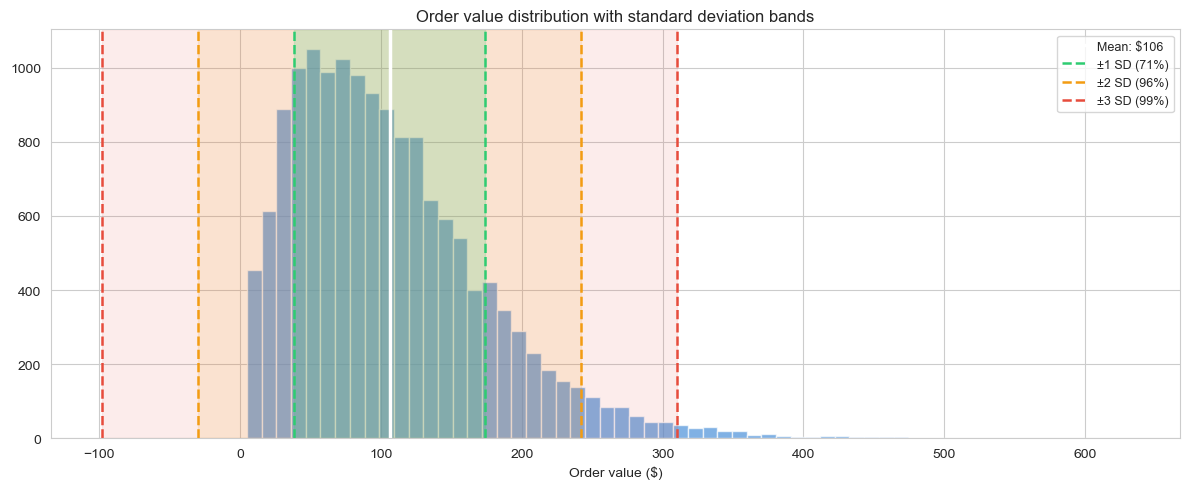

In [41]:
std = values.std()
within_1sd = ((values >= mean - std) & (values <= mean + std)).mean()
within_2sd = ((values >= mean - 2*std) & (values <= mean + 2*std)).mean()
within_3sd = ((values >= mean - 3*std) & (values <= mean + 3*std)).mean()
print(f"Within 1 SD (${mean-std:.0f} - ${mean+std:.0f}): {within_1sd:.1%}  (theory: 68%)")
print(f"Within 2 SD (${mean-2*std:.0f} - ${mean+2*std:.0f}): {within_2sd:.1%}  (theory: 95%)")
print(f"Within 3 SD (${mean-3*std:.0f} - ${mean+3*std:.0f}): {within_3sd:.1%}  (theory: 99.7%)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(values, bins=60, color='#4A90D9', edgecolor='white', alpha=0.7)
# Shade the 1, 2, 3 std dev bands
for sd, color, alpha in [(3,'#E74C3C',0.10),(2,'#F39C12',0.12),
(1,'#2ECC71',0.18)]:
 ax.axvspan(mean - sd*std_manual, mean + sd*std_manual, alpha=alpha, color=color)
ax.axvline(mean, color='white', linewidth=2.5, label=f'Mean: ${mean:.0f}')
ax.axvline(mean - std_manual, color='#2ECC71', linewidth=1.8, linestyle='--')
ax.axvline(mean + std_manual, color='#2ECC71', linewidth=1.8, linestyle='--',
 label=f'±1 SD ({within_1sd:.0%})')
ax.axvline(mean - 2*std_manual, color='#F39C12', linewidth=1.8, linestyle='--')
ax.axvline(mean + 2*std_manual, color='#F39C12', linewidth=1.8, linestyle='--',
 label=f'±2 SD ({within_2sd:.0%})')
ax.axvline(mean - 3*std_manual, color='#E74C3C', linewidth=1.8, linestyle='--')
ax.axvline(mean + 3*std_manual, color='#E74C3C', linewidth=1.8, linestyle='--',
 label=f'±3 SD ({within_3sd:.0%})')
ax.set_title('Order value distribution with standard deviation bands')
ax.set_xlabel('Order value ($)')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()